In [1]:
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [3]:
## Dataset Analysis

In [4]:
dataset_location = '/content/drive/MyDrive/Dataset'

In [5]:
def check_consistent_columns(dataset_location):
    """
    Checks if all CSV files in a directory have the same columns.

    Args:
        dataset_location: The path to the directory containing the CSV files.

    Returns:
        True if all CSV files have the same columns, False otherwise.
        Also prints informative messages about discrepancies.
    """

    csv_files = [f for f in os.listdir(dataset_location) if f.endswith('.csv')]
    if not csv_files:
        print("No CSV files found in the specified directory.")
        return False

    first_csv_columns = None
    consistent = True

    for filename in csv_files:
        filepath = os.path.join(dataset_location, filename)
        try:
          df = pd.read_csv(filepath)
          if first_csv_columns is None:
              first_csv_columns = set(df.columns)
          elif set(df.columns) != first_csv_columns:
              consistent = False
              print(f"Inconsistent columns found in file: {filename}")
              print(f"Columns in {filename}: {set(df.columns)}")
              print(f"Expected columns: {first_csv_columns}")
              #print difference in columns
              print(f"Missing columns in {filename}: {first_csv_columns - set(df.columns)}")
              print(f"Extra columns in {filename}: {set(df.columns) - first_csv_columns}")

        except pd.errors.EmptyDataError:
            print(f"Warning: {filename} is empty.")
            consistent = False
        except pd.errors.ParserError:
            print(f"Warning: Could not parse {filename}. Please check its format.")
            consistent = False
        except Exception as e:
          print(f"An error occurred while processing {filename}: {e}")
          consistent = False

    if consistent:
        print("All CSV files have the same columns.")

    return consistent

check_consistent_columns(dataset_location)

Inconsistent columns found in file: 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv
Columns in 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv: {'dev60_HR', 'RR', 'ScalcO2', 'dev60_PI', 'Sample', 'dev64_SpO2', 'dev64_HR', 'Timestamp', 'dev60_SpO2', 'dev59_SpO2', 'ETCO2', 'dev59_HR', 'dev64_PI', 'dev59_PI', 'ETO2'}
Expected columns: {'dev60_HR', 'RR', 'ScalcO2', 'dev60_PI', 'Sample', 'Timestamp', 'dev60_SpO2', 'dev59_SpO2', 'ETCO2', 'dev59_HR', 'dev59_PI', 'ETO2'}
Missing columns in 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv: set()
Extra columns in 0be700eb88a7225db22a71124b732d8bc6323f7d5b9625db31a789129a6e2f23_2hz.csv: {'dev64_HR', 'dev64_SpO2', 'dev64_PI'}
Inconsistent columns found in file: 0c4add4ddcafc4e85656b66e0ac81943fb5463d6540702358e65e8d840d87f68_2hz.csv
Columns in 0c4add4ddcafc4e85656b66e0ac81943fb5463d6540702358e65e8d840d87f68_2hz.csv: {'dev60_HR', 'RR', 'ScalcO2', 'dev60_PI', 'Sample', 'dev64_

False

In [6]:
def get_common_columns(dataset_location):
    """
    Identifies columns common to all CSV files in a directory.

    Args:
        dataset_location: The path to the directory.

    Returns:
        A set of column names common to all CSV files, or None if an error occurs
        or no CSV files are found.
    """
    csv_files = [f for f in os.listdir(dataset_location) if f.endswith('.csv')]
    if not csv_files:
        print("No CSV files found in the specified directory.")
        return None

    common_columns = None
    for filename in csv_files:
        filepath = os.path.join(dataset_location, filename)
        try:
            df = pd.read_csv(filepath)
            current_columns = set(df.columns)
            if common_columns is None:
                common_columns = current_columns
            else:
                common_columns = common_columns.intersection(current_columns)
        except (pd.errors.EmptyDataError, pd.errors.ParserError, FileNotFoundError) as e:
            print(f"Warning: Could not process {filename}: {e}")
            return None  # Return None if any file has an error
        except Exception as e:
            print(f"An unexpected error occurred while processing {filename}: {e}")
            return None

    return common_columns


common_cols = get_common_columns(dataset_location)

if common_cols:
    print("Common columns in all CSV files:")
    for col in common_cols:
      print(col)

Common columns in all CSV files:
dev60_PI
dev60_SpO2
dev59_SpO2
dev59_HR
dev59_PI


In [7]:
def combine_csv_files(dataset_location, common_cols):
    """Combines CSV files based on common columns."""

    all_dataframes = []
    csv_files = [f for f in os.listdir(dataset_location) if f.endswith('.csv')]

    if not csv_files:
        print("No CSV files found in the specified directory.")
        return None

    for filename in csv_files:
        filepath = os.path.join(dataset_location, filename)
        try:
            df = pd.read_csv(filepath)
            #Keep only common columns
            df = df[list(common_cols)]
            all_dataframes.append(df)
        except (pd.errors.EmptyDataError, pd.errors.ParserError) as e:
            print(f"Warning: Could not process {filename}: {e}")
            continue # Skip to the next file
        except Exception as e:
            print(f"An unexpected error occurred while processing {filename}: {e}")
            continue #Skip to the next file


    if not all_dataframes:
      print("No valid CSV files to combine.")
      return None

    combined_df = pd.concat(all_dataframes, ignore_index=True)
    return combined_df

# Example usage
combined_data = combine_csv_files(dataset_location, common_cols)

if combined_data is not None:
    # Save the combined DataFrame to a new CSV file
    combined_data.to_csv(os.path.join(dataset_location, 'combined_dataset.csv'), index=False)
    print("Combined CSV file 'combined_dataset.csv' created successfully.")

Combined CSV file 'combined_dataset.csv' created successfully.


In [8]:
# Import the combined dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/combined_dataset.csv')

In [9]:
print(df.shape)

(299408, 5)


In [10]:
df.head()

,dev60_PI,dev60_SpO2,dev59_SpO2,dev59_HR,dev59_PI
0,820.0,NaN,88.0,75.0,8.0
1,0.4,100.0,88.0,74.0,6.0
2,0.4,100.0,88.0,74.0,6.0
3,0.4,100.0,88.0,74.0,7.0
4,0.4,100.0,88.0,74.0,7.0


In [11]:
df_cols = df.columns
print(df_cols)

Index(['dev60_PI', 'dev60_SpO2', 'dev59_SpO2', 'dev59_HR', 'dev59_PI'], dtype='object')


In [12]:
df.describe()

,dev60_PI,dev60_SpO2,dev59_SpO2,dev59_HR,dev59_PI
count,289570.000000,2.896370e+05,293894.000000,293838.000000,290451.000000
mean,3.088974,1.040188e+04,44.240352,37.690510,14.400694
std,12.383023,5.574418e+06,45.585325,40.628840,25.838773
min,-0.379034,-2.776496e-03,-3.723528,-3.933258,-0.975660
25%,-0.234530,-2.764501e-03,0.299332,0.008772,-0.296180
50%,0.200000,7.183751e-19,1.040385,1.736785,1.946104
75%,2.600000,9.400000e+01,94.000000,78.000000,19.000000
max,820.000000,3.000037e+09,100.000000,255.000000,255.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299408 entries, 0 to 299407
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   dev60_PI    289570 non-null  float64
 1   dev60_SpO2  289637 non-null  float64
 2   dev59_SpO2  293894 non-null  float64
 3   dev59_HR    293838 non-null  float64
 4   dev59_PI    290451 non-null  float64
dtypes: float64(5)
memory usage: 11.4 MB


In [14]:
# Drop timestamp as it is of object type
if 'Timestamp' in df.columns:
    df.drop('Timestamp', axis=1, inplace=True)

In [15]:
# Find number of entries missing in each column

missing_values_per_column = df.isnull().sum()
missing_values_per_column

,0
dev60_PI,9838
dev60_SpO2,9771
dev59_SpO2,5514
dev59_HR,5570
dev59_PI,8957


In [16]:
# Drop columns with more than 10000 missing values
threshold = 10000
df = df.dropna(thresh=len(df) - threshold, axis=1)

In [17]:
df.head()

,dev60_PI,dev60_SpO2,dev59_SpO2,dev59_HR,dev59_PI
0,820.0,NaN,88.0,75.0,8.0
1,0.4,100.0,88.0,74.0,6.0
2,0.4,100.0,88.0,74.0,6.0
3,0.4,100.0,88.0,74.0,7.0
4,0.4,100.0,88.0,74.0,7.0


In [18]:
from sklearn.impute import SimpleImputer

# Create a SimpleImputer object with your preferred strategy (e.g., mean, median, most_frequent)
imputer = SimpleImputer(strategy='mean')  # Replace 'mean' with 'median' or 'most_frequent' if needed

# Fit the imputer on the numerical columns of your DataFrame
numerical_cols = df.select_dtypes(include=np.number).columns
imputer.fit(df[numerical_cols])

# Transform the DataFrame to fill missing values
df[numerical_cols] = imputer.transform(df[numerical_cols])

#Now check for any remaining missing values
missing_values_per_column = df.isnull().sum()
missing_values_per_column

,0
dev60_PI,0
dev60_SpO2,0
dev59_SpO2,0
dev59_HR,0
dev59_PI,0


In [19]:
## EDA

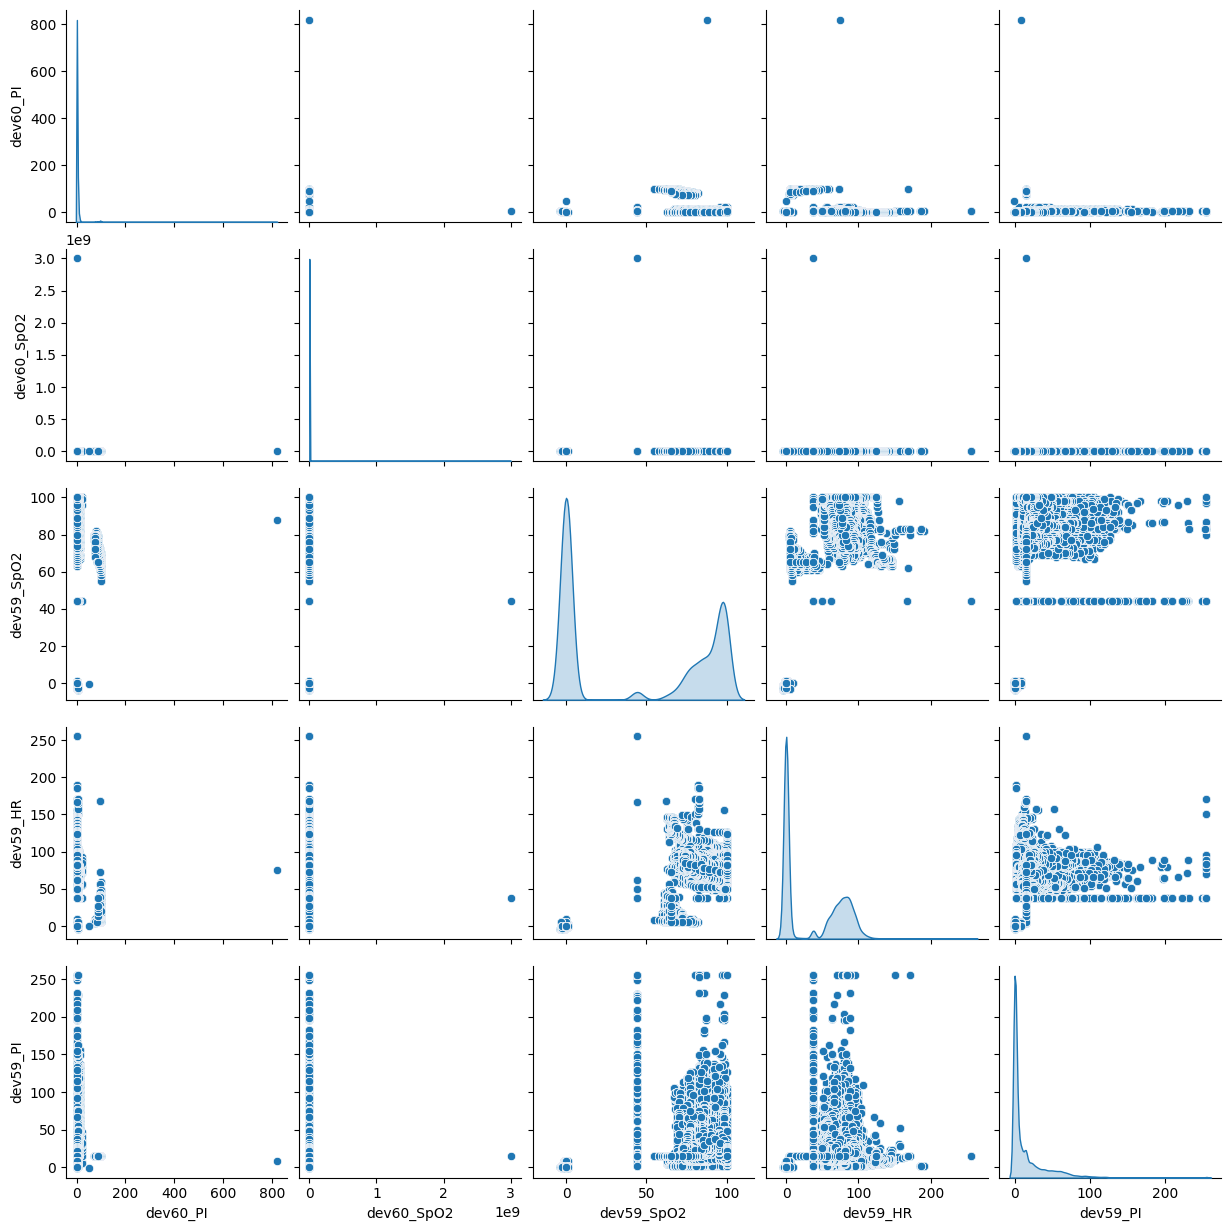

In [20]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Pairplot for visualizing relationships between features
sns.pairplot(df, diag_kind='kde') #kde for density plot on diagonal
plt.show()

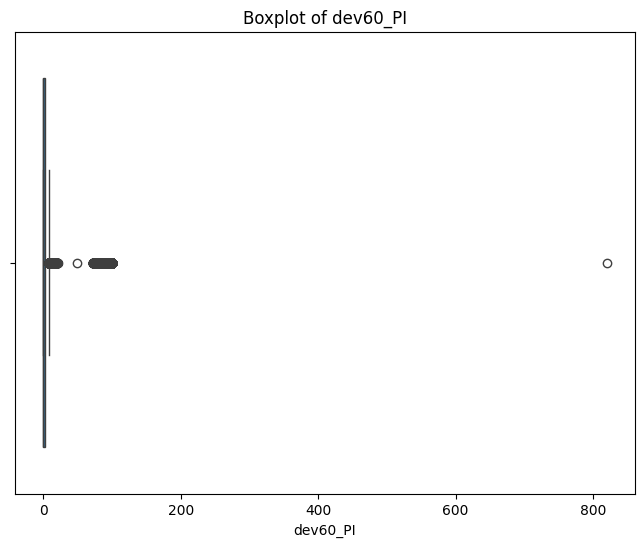

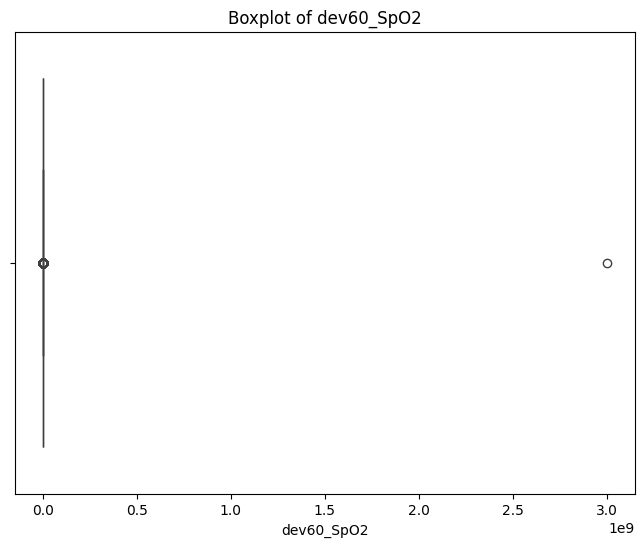

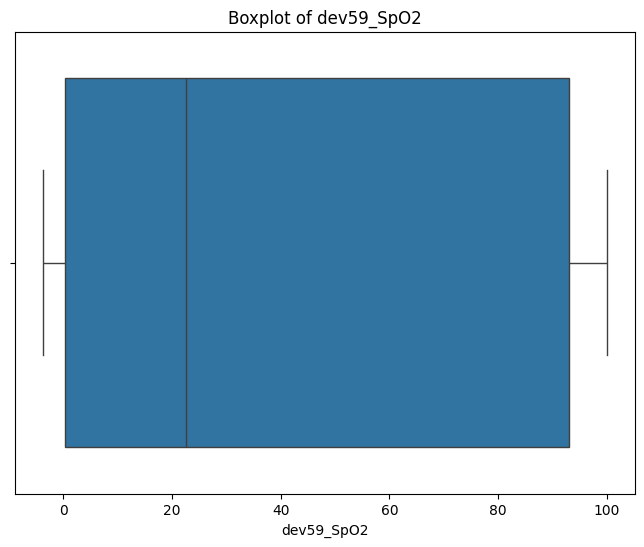

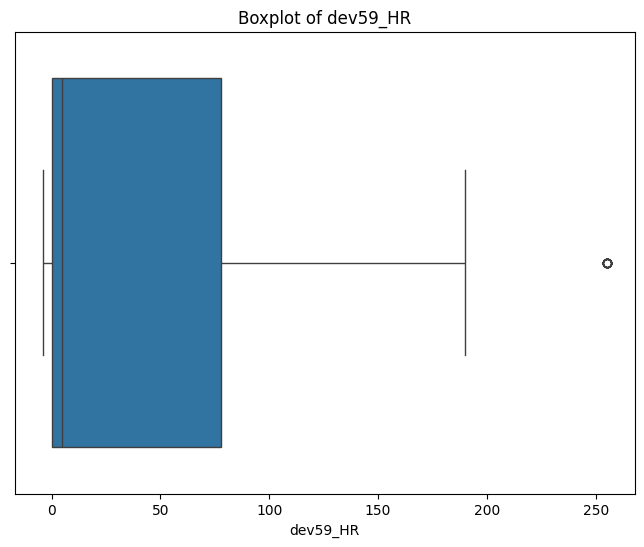

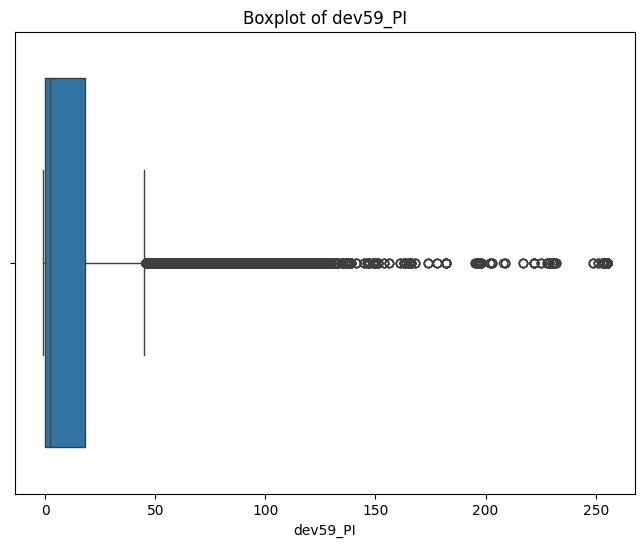

In [21]:
# Boxplots for each feature to check for outliers
for col in df.columns:
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [22]:
# Histograms for distribution of features
# for col in df.columns:
#     plt.figure(figsize=(8,6))
#     sns.histplot(df[col], kde=True) #kde to show distribution
#     plt.title(f'Distribution of {col}')
#     plt.show()

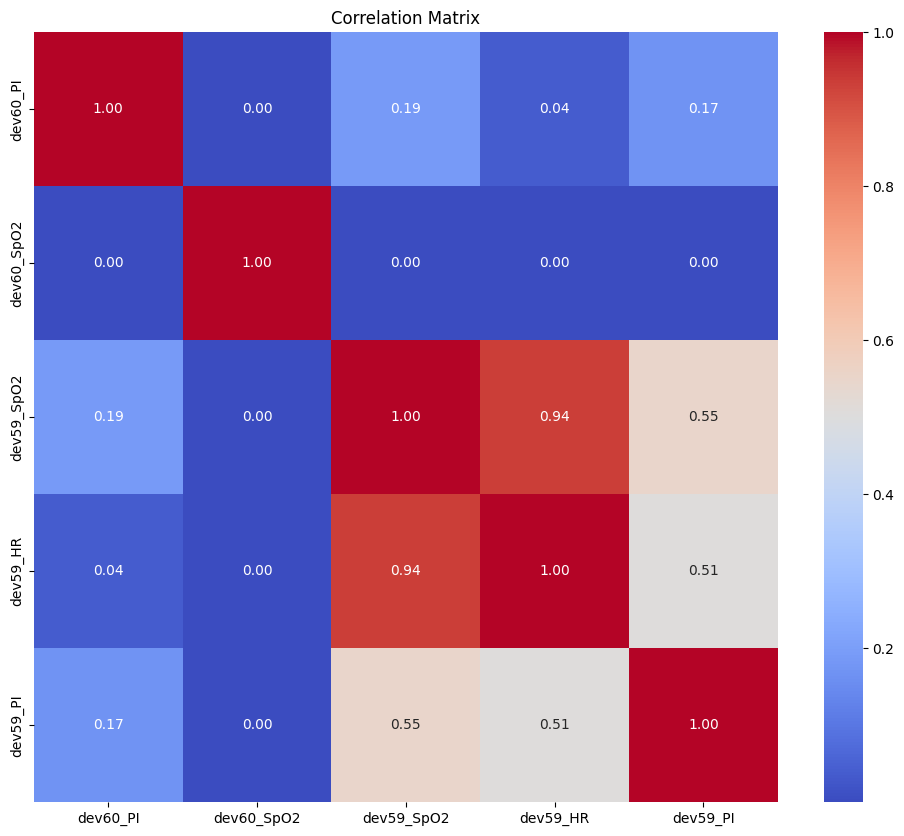

In [23]:
# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Highly correlated to dev59_HR

# Drop 'dev60_HR' if it exists in the DataFrame
if 'dev60_HR' in df.columns:
    df.drop('dev60_HR', axis=1, inplace=True)

In [25]:
## Scaling the data

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on your numerical data
numerical_cols = df.select_dtypes(include=np.number).columns
scaler.fit(df[numerical_cols])

# Transform the numerical data using the fitted scaler
df[numerical_cols] = scaler.transform(df[numerical_cols])

In [26]:
## Model Training

In [27]:
# K-Means

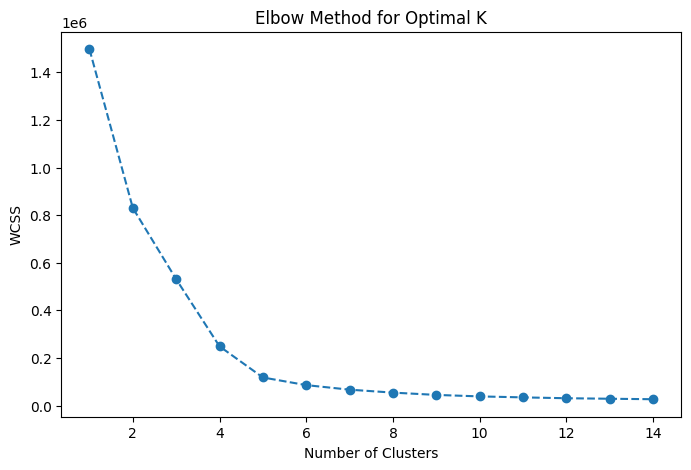

In [28]:
# Determine optimal K using Elbow Method
wcss = []
k_values = range(1, 15)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [29]:
## From the elbow method the ideal value of K=5

In [30]:
optimal_k = 5  # Adjust based on elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df)

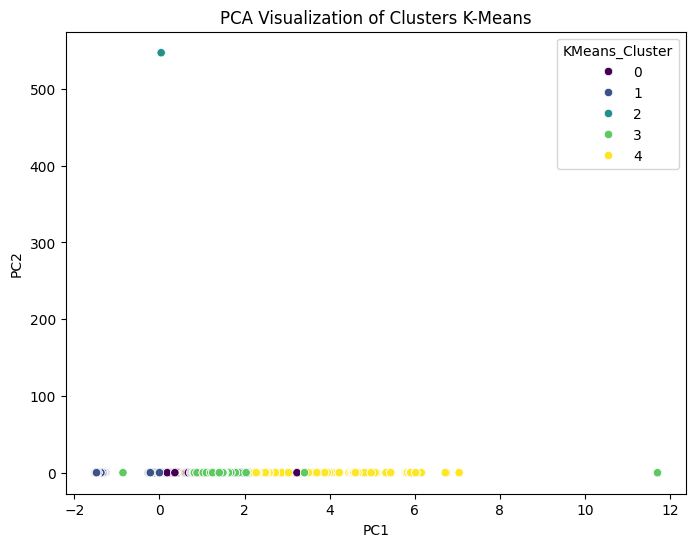

In [31]:
# Visualizing clusters using PCA
pca = PCA(n_components=2)
df_pca = pd.DataFrame(pca.fit_transform(df.drop(columns=['KMeans_Cluster'])), columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = df['KMeans_Cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis')
plt.title('PCA Visualization of Clusters K-Means')
plt.show()

# Save clustered data
df.to_csv("/content/drive/MyDrive/Dataset/clustered_patients.csv", index=False)

In [32]:
## DBScan

In [ ]:
# dbscan = DBSCAN(eps=1.5, min_samples=10)  # Adjust eps and min_samples based on dataset
# df["DBSCAN_Cluster"] = dbscan.fit_predict(df)

In [ ]:
## Evaluation
"""
Silhouette Score - Measures how well each sample fits within its cluster.
Davies-Bouldin Index - Evaluates the average similarity ratio between clusters.
Calinski-Harabasz Index - Measures the compactness and separation of clusters.
"""

In [ ]:
# Evaluate Clustering Performance
def evaluate_clustering(data, labels, method_name):
    # Only evaluate if we have more than 1 cluster
    if len(set(labels)) > 1 and -1 not in set(labels):
        silhouette = silhouette_score(data, labels)
        davies_bouldin = davies_bouldin_score(data, labels)
        calinski_harabasz = calinski_harabasz_score(data, labels)
    else:
        silhouette, davies_bouldin, calinski_harabasz = np.nan, np.nan, np.nan

    print(f"\n{method_name} Clustering Evaluation:")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")


In [ ]:
# evaluate_clustering(df.drop(columns=["KMeans_Cluster", "DBSCAN_Cluster"]), df["KMeans_Cluster"], "KMeans")
# evaluate_clustering(df.drop(columns=["KMeans_Cluster", "DBSCAN_Cluster"]), df["DBSCAN_Cluster"], "DBSCAN")